# Laboratorio 4 (Parte 2) — Inciso 8: Interpretación y explicabilidad del modelo

Se toma el modelo con mejor desempeño del inciso 5 (mayor F2-score, el criterio orientado a Recall definido en el 5.3) y se interpreta con importancia global de variables y con SHAP.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from src.config import RUTA_DATA_PROCESSED, RUTA_FIGURAS
from src.modelado import PREDICTORES, cargar_modelo, importancia_global

metricas = pd.read_csv(RUTA_DATA_PROCESSED / "p2_metricas_modelos.csv", index_col=0)
criterio = "f2" if "f2" in metricas.columns else "roc_auc"
mejor_nombre = metricas[criterio].idxmax()
modelo = cargar_modelo(mejor_nombre)
print(f"Mejor modelo según {criterio}: {mejor_nombre}")

test = pd.read_parquet(RUTA_DATA_PROCESSED / "p2_test_set.parquet")
X_test = test[PREDICTORES]

Mejor modelo según f2: random_forest


## 8.1 Importancia global de variables

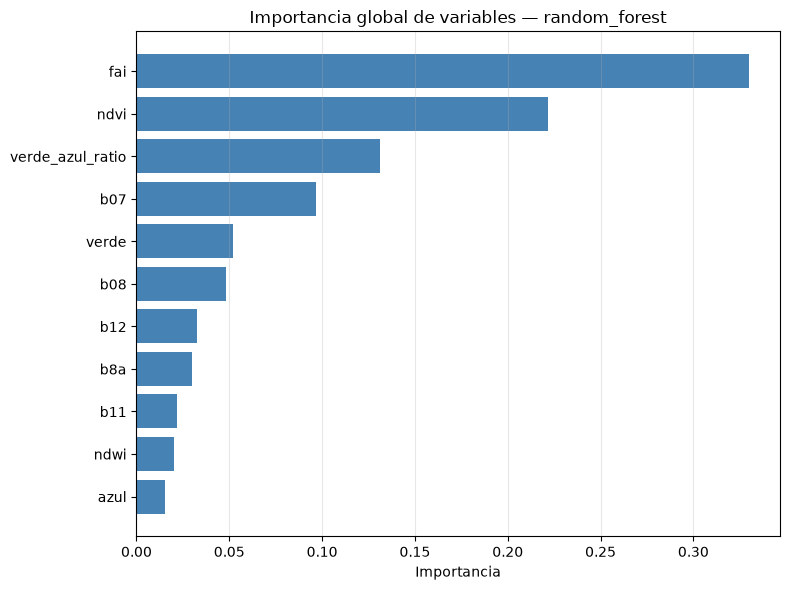

In [2]:
importancia = importancia_global(modelo)
importancia.to_csv(RUTA_DATA_PROCESSED / "p2_importancia_variables.csv", header=["importancia"])

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importancia.index[::-1], importancia.values[::-1], color="steelblue")
ax.set_xlabel("Importancia" if hasattr(modelo, "feature_importances_") else "|Coeficiente estandarizado|")
ax.set_title(f"Importancia global de variables — {mejor_nombre}")
ax.grid(alpha=0.3, axis="x")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "p2_importancia_variables.png", dpi=150)
plt.show()

## 8.2 SHAP Summary Plot

Se calculan valores SHAP sobre una submuestra del conjunto de prueba (2,000 observaciones), suficiente para un resumen estable sin el costo de explicar el conjunto completo. Para Random Forest y Gradient Boosting se usa `shap.TreeExplainer`, exacto y eficiente sobre modelos de árboles; para Regresión Logística (dentro de un `Pipeline` con escalado) se usa el `shap.Explainer` genérico sobre `predict_proba`, con una muestra de referencia (`background`).

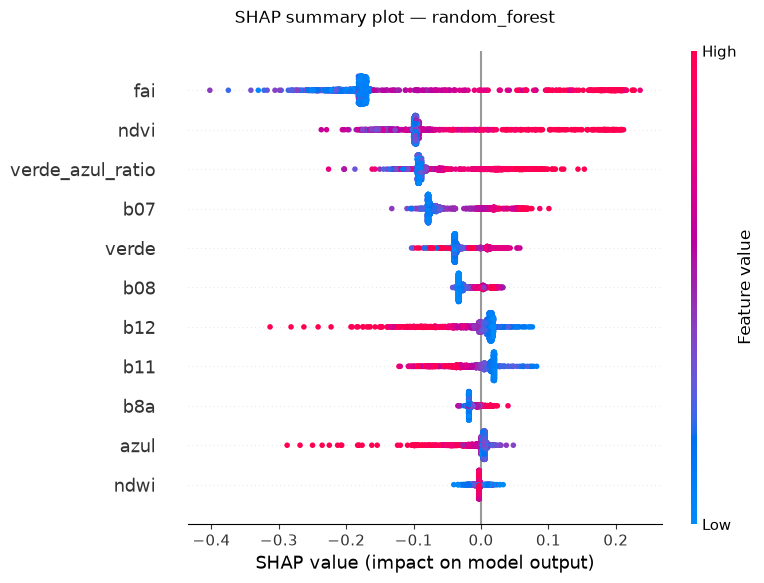

In [3]:
rng = np.random.default_rng(42)
idx_shap = rng.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_shap = X_test.iloc[idx_shap]

if hasattr(modelo, "feature_importances_"):
    explainer = shap.TreeExplainer(modelo)
    shap_values = explainer(X_shap).values
else:
    background = shap.sample(X_test, 100, random_state=0)
    explainer = shap.Explainer(modelo.predict_proba, background)
    shap_values = explainer(X_shap).values

# Para modelos con salida por clase (Random Forest, Regresión Logística), se conserva la
# contribución hacia la clase 1 (alta presencia de cianobacteria).
if shap_values.ndim == 3:
    shap_values = shap_values[..., 1]

shap.summary_plot(shap_values, X_shap, feature_names=PREDICTORES, show=False)
fig = plt.gcf()
fig.suptitle(f"SHAP summary plot — {mejor_nombre}")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "p2_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 8.3 y 8.4 Variables de mayor influencia e interpretación ambiental

*(Completar tras ejecutar: identificar en `p2_shap_summary.png` las 3-4 variables con mayor dispersión de valores SHAP -las de mayor influencia- y si los puntos de color alto (valor de la variable alto) se ubican predominantemente a la derecha (aumentan la predicción de alta presencia) o a la izquierda (la disminuyen).)*

Interpretación ambiental esperada, a confirmar con el gráfico real:

- **`ndvi` y `verde_azul_ratio`**: se espera que valores altos empujen la predicción hacia "alta presencia". Ambas variables capturan, de forma indirecta, la señal de pigmentos fotosintéticos (biomasa algal, absorción de clorofila) que también produce el NDCI excluido en el inciso 2.5, consistente con su correlación positiva ya observada en el inciso 3.
- **`ndwi`**: se espera que valores altos empujen la predicción hacia "baja presencia". Un NDWI alto indica agua "limpia", con poca interferencia de materia en suspensión; las floraciones dispersan más luz visible/NIR y reducen esta señal.
- **`fai` y `b8a`**: se espera que valores altos, asociados a materia flotante en superficie, empujen la predicción hacia "alta presencia", coherente con el diseño del Floating Algae Index para detectar acumulaciones superficiales de algas.
- **Bandas SWIR (`b11`, `b12`)**: se espera una influencia más moderada y menos monótona que las anteriores, aportando información complementaria sobre turbidez/sedimento más que una señal directa de biomasa algal.

Si el modelo con mejor desempeño resulta ser Random Forest o Gradient Boosting, es esperable que el orden de importancia en `p2_importancia_variables.png` sea consistente con el patrón de dispersión del SHAP summary plot, aunque no necesariamente idéntico: la importancia global promedia el efecto absoluto de cada variable, mientras que SHAP además muestra la dirección del efecto para cada observación individual.

### Self-check

In [4]:
assert set(importancia.index) == set(PREDICTORES)
assert (importancia.diff().dropna() <= 0).all(), "importancia_global no quedó ordenada de mayor a menor"
assert shap_values.shape == (len(X_shap), len(PREDICTORES))
assert np.isfinite(shap_values).all(), "hay valores SHAP no finitos"
print(f"OK: importancia global y SHAP summary plot generados para {mejor_nombre}.")

OK: importancia global y SHAP summary plot generados para random_forest.
